In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cell2location
import os
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
import pandas as pd

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

os.chdir(".")
os.getcwd()

E:\Anaconda\envs\cell2loc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


'F:\\20240911_毕业论文'

In [2]:
torch.cuda.current_device()

0

In [3]:
ad_sp = sc.read_visium('空转数据/WK4/outs/')
ad_sp.var_names_make_unique()
ad_sp.obs['orig.ident'] = 'WK4'
ad_sp

E:\Anaconda\envs\cell2loc\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
E:\Anaconda\envs\cell2loc\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4368 × 19144
    obs: 'in_tissue', 'array_row', 'array_col', 'orig.ident'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [4]:
# find mitochondria-encoded (MT) genes
ad_sp.var['MT_gene'] = [gene.startswith('MT-') for gene in ad_sp.var_names]
# remove MT genes for spatial mapping (keeping their counts in the object)
ad_sp.obsm['MT'] = ad_sp[:, ad_sp.var['MT_gene'].values].X.toarray()
ad_sp = ad_sp[:, ~ad_sp.var['MT_gene'].values]

In [5]:
ad_sc = sc.read_h5ad('树突细胞/dc_macro.h5ad')
ad_sc

AnnData object with n_obs × n_vars = 20942 × 38343
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'dataset', 'grade', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'SCT_snn_res.0.1', 'SCT_snn_res.0.03', 'class', 'celltype'
    uns: 'harmony', 'pca'
    obsm: 'X_harmony', 'X_pca'
    varm: 'PCs', 'harmony'

E:\Anaconda\envs\cell2loc\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


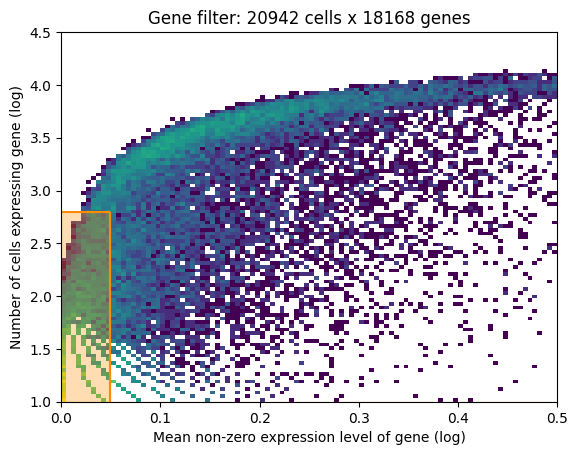

In [6]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(ad_sc, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

In [7]:
# filter the object
ad_sc = ad_sc[:, selected].copy()

In [8]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(
    adata = ad_sc,
    batch_key = 'dataset',
    labels_key = 'celltype'
   )

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [9]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(ad_sc)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'dataset',
│   'labels_key': 'celltype',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  40   │
│         n_cells          │ 20942 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   6   │
│          n_vars          │ 18168 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['dataset'] │    d1s1    │          0          │
│                      │    d1s2    │          1          │
│                      │    d2s1    │          2          │
│                      │    d2s2    │          3          │
│                      │    d2s3    │          4          │
│                      │    d2s4    │          5          │
│                      │    d2s5    │          6          │
│                      │    d2s6    │          7          │
│                      │    d3s1    │          8          │
│                      │   d3s10    │          9          │
│                      │    d3s2    │         10          │
│                      │    d3s3    │         11          │
│                      │    d3s4    │         12          │
│                      │    d3s5    │         13          │
│                      │    d3s6    │         14          │
│                      │    d3s7    │         15          │
│                      │    d3s8    │         16          │
│                      │    d3s9    │         17          │
│                      │    d4s1    │         18          │
│                      │    d4s2    │         19          │
│                      │    d4s3    │         20          │
│                      │    d4s4    │         21          │
│                      │    d4s5    │         22          │
│                      │    d4s6    │         23          │
│                      │    d4s7    │         24          │
│                      │    d4s8    │         25          │
│                      │    d4s9    │         26          │
│                      │    d5s1    │         27          │
│                      │    d5s2    │         28          │
│                      │    d5s3    │         29          │
│                      │    d5s4    │         30          │
│                      │    d5s5    │         31          │
│                      │    d5s6    │         32          │
│                      │    d6s1    │         33          │
│                      │    d6s2    │         34          │
│                      │    d6s3    │         35          │
│                      │    d6s4    │         36          │
│                      │    d6s5    │         37          │
│                      │    d6s6    │         38          │
│                      │    d6s7    │         39          │
└──────────────────────┴────────────┴─────────────────────┘

                   labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype'] │    DC_1    │          0          │
│                       │    DC_2    │          1          │
│                       │   Langer   │          2          │
│                       │ Langer_M2  │          3          │
│                       │  M1_Macro  │          4          │
│                       │  M2_Macro  │          5          │
└───────────────────────┴────────────┴─────────────────────┘

In [10]:
mod.train(max_epochs = 250, use_gpu = True, train_size = 1)

E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\train\_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
E:\Anaconda\envs\cell2loc\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 3050') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

Epoch 250/250: 100%|████████████████████████████████████| 250/250 [11:33<00:00,  2.79s/it, v_num=1, elbo_train=1.78e+8]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|████████████████████████████████████| 250/250 [11:33<00:00,  2.77s/it, v_num=1, elbo_train=1.78e+8]


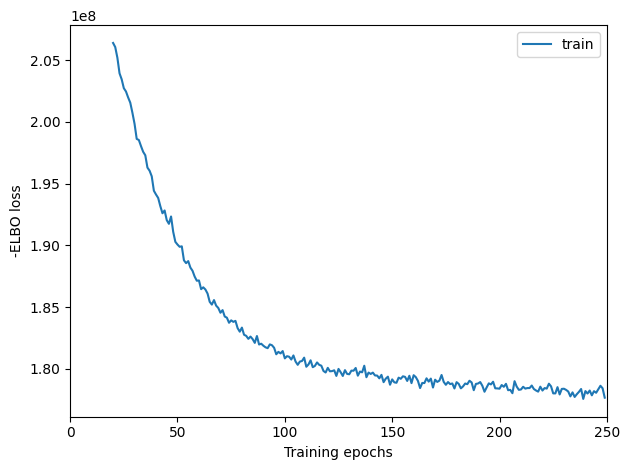

In [11]:
mod.plot_history(20)

In [12]:
ad_sc = mod.export_posterior(
    ad_sc, sample_kwargs={'num_samples': 1000, 'batch_size': 2500, 'use_gpu': True}
)

E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\model\base\_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|█████████████████████████████████████████████| 999/999 [00:18<00:00, 54.94it/s]


In [13]:
ad_sc = mod.export_posterior(
    ad_sc, use_quantiles = True,
    add_to_varm = ["q05","q50", "q95", "q0001"],
    sample_kwargs = {'batch_size': 2500, 'use_gpu': True}
)

In [14]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in ad_sc.varm.keys():
    inf_aver = ad_sc.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}' for i in ad_sc.uns['mod']['factor_names']]].copy()
else:
    inf_aver = ad_sc.var[[f'means_per_cluster_mu_fg_{i}' for i in ad_sc.uns['mod']['factor_names']]].copy()
inf_aver.columns = ad_sc.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:15]

,DC_1,DC_2,Langer,Langer_M2,M1_Macro,M2_Macro
AP006222.2,0.000422,0.000799,0.000377,0.000267,0.001218,0.001798
SAMD11,0.002710,0.000793,0.001843,0.002385,0.002290,0.002011
NOC2L,0.144535,0.128279,0.326113,0.252476,0.199085,0.392358
PLEKHN1,0.064181,0.002240,0.022912,0.016839,0.013974,0.037607
RP11-54O7.17,0.000244,0.000534,0.000540,0.000161,0.000592,0.000954


In [15]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(ad_sp.var_names, inf_aver.index)
ad_sp = ad_sp[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata = ad_sp, batch_key = "orig.ident")

In [16]:
# create and train the model
mod = cell2location.models.Cell2location(
    ad_sp, cell_state_df = inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'orig.ident',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4368  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 14274 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['orig.ident'] │    WK4     │          0          │
└─────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\train\_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
E:\Anaconda\envs\cell2loc\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
E:\Anaconda\envs\cell2loc\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:281: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 30000/30000: 100%|██████████████████████████| 30000/30000 [1:59:43<00:00,  4.18it/s, v_num=1, elbo_train=4.49e+7]

`Trainer.fit` stopped: `max_epochs=30000` reached.


Epoch 30000/30000: 100%|██████████████████████████| 30000/30000 [1:59:43<00:00,  4.18it/s, v_num=1, elbo_train=4.49e+7]


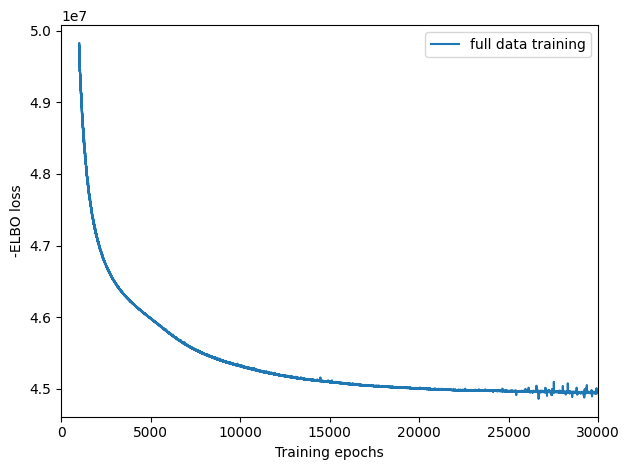

In [17]:
mod.train(max_epochs = 30000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1,
          use_gpu=True,
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training'])

In [18]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
ad_sp = mod.export_posterior(
    ad_sp, sample_kwargs = {'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': True}
)

E:\Anaconda\envs\cell2loc\Lib\site-packages\scvi\model\base\_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|█████████████████████████████████████████████| 999/999 [00:33<00:00, 29.60it/s]


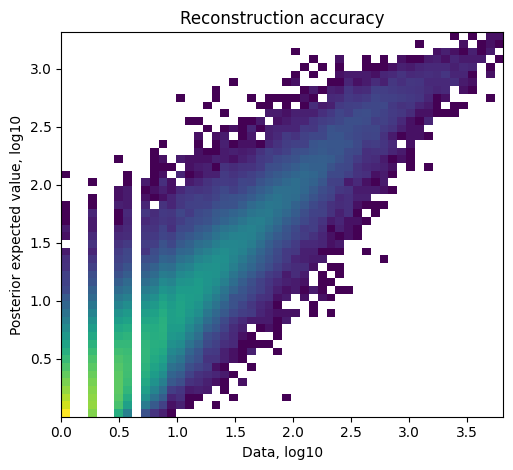

In [19]:
mod.plot_QC()

In [20]:
cluster_abundance = pd.DataFrame(ad_sp.obsm['q05_cell_abundance_w_sf'])
cluster_abundance.to_csv('cell2loc_WK1.csv')

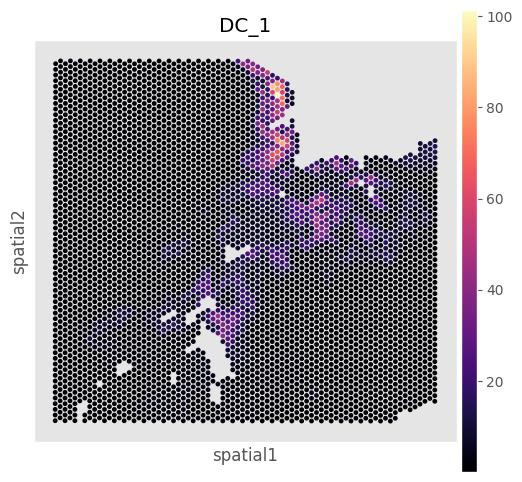

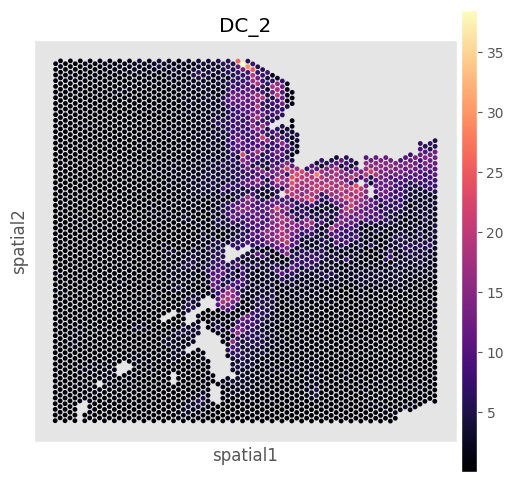

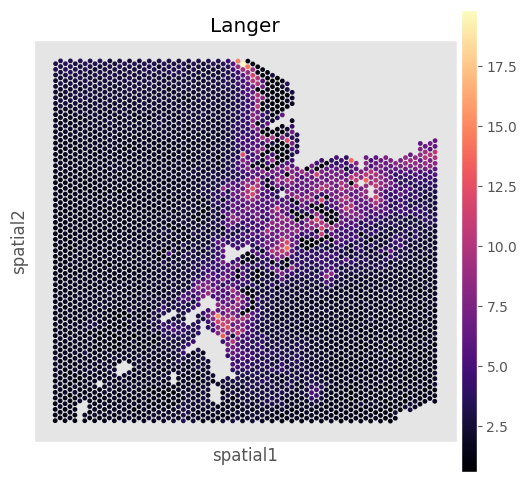

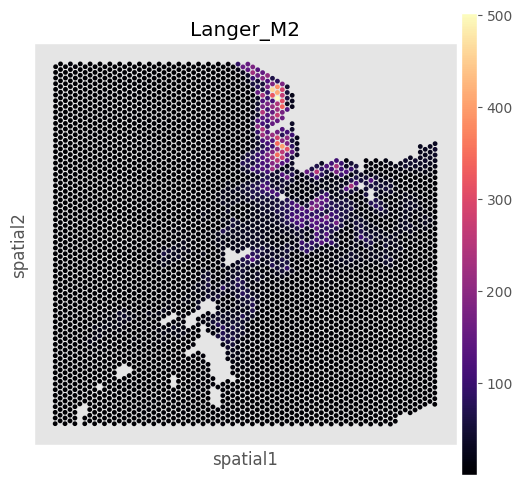

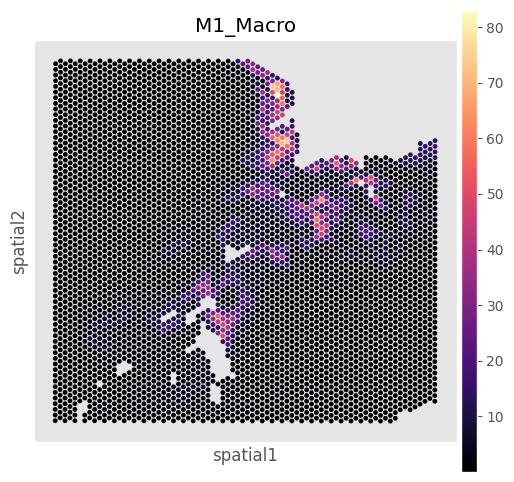

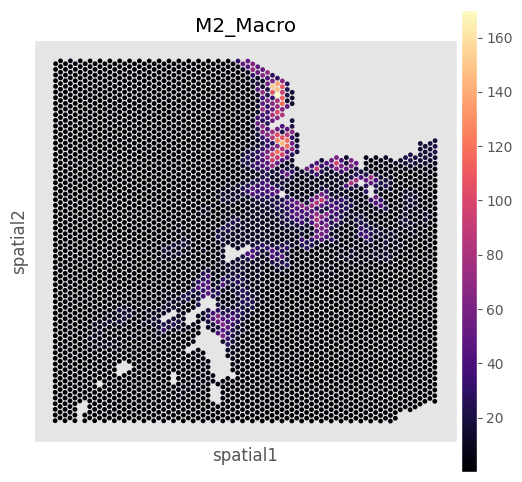

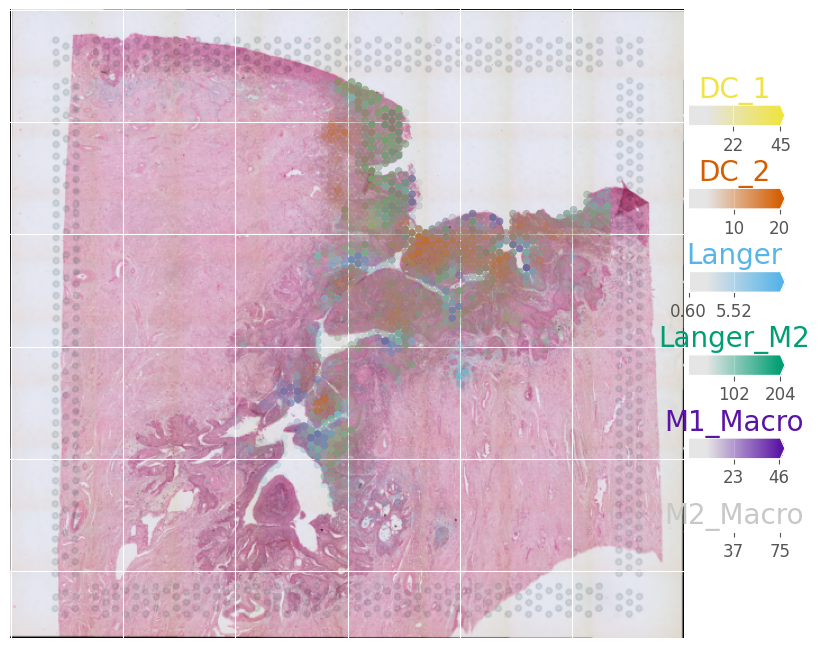

In [21]:
### 可视化
ad_sp.obs[ad_sp.uns['mod']['factor_names']] = ad_sp.obsm['q05_cell_abundance_w_sf']

### 一个细胞类型一张图
plt.rcParams["figure.figsize"] = (6, 6)
plt.style.use('ggplot')
for cluster in ['DC_1', 'DC_2', 'Langer', 'Langer_M2', 'M1_Macro', 'M2_Macro']:
    sc.pl.spatial(ad_sp, cmap = 'magma', color = cluster, size = 1.3, img_key = None, show = False)
    plt.gca().set_aspect('equal', 'box')
    plt.savefig('Cluster_'+ cluster + '.png', dpi = 300, transparent = False, bbox_inches = 'tight')

### 所有细胞类型一张图
from cell2location.plt import plot_spatial

# select up to 6 clusters
clust_labels = ['DC_1', 'DC_2', 'Langer', 'Langer_M2', 'M1_Macro', 'M2_Macro']
clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

with mpl.rc_context({'figure.figsize': (10, 10)}):
    fig = plot_spatial(
        adata=ad_sp,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        img_key='lowres',
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=5,
        colorbar_position='right'
    )
plt.gca().set_aspect('equal', 'box')
plt.savefig('cell2loc_merge.png', dpi = 300, transparent = False, bbox_inches = 'tight')